# ML Notebook — Cambodia Education Forecast (Lag Features Version)

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data & Engineer Targets

In [10]:
import os
if os.path.exists('../data/cleaned_new_data.csv'):
    df = pd.read_csv('../data/cleaned_new_data.csv')
else:
    df = pd.read_csv('data/cleaned_new_data.csv')
# df = df[df['Year'] != 2021].reset_index(drop=True)

# Targets
repetition_cols = [f'g{i}_repetition' for i in range(1, 13)]
df['avg_repetition_rate'] = df[repetition_cols].mean(axis=1)

dropout_cols = [f'g{i}_dropout' for i in range(1, 13)]
df['avg_dropout_rate'] = df[dropout_cols].mean(axis=1)

overage_cols = ['pct_overage_enrollment_primary',
                'pct_overage_enrollment_lower_sec',
                'pct_overage_enrollment_upper_sec']
df['over_age_enrollment_total'] = df[overage_cols].sum(axis=1)
df['avg_transition_rate'] = df[['transition_rate_lower_sec_total',
                                 'transition_rate_upper_sec_total']].mean(axis=1)

df['kids_population'] = df[['pop_aged6_total','pop_aged6_11_total',
                              'pop_aged12_14_total','pop_aged15_17_total']].sum(axis=1)
df['bad_qual_teacher']  = df[['teaching_staff_edu_primary',
                               'teaching_staff_edu_lower_sec',
                               'teaching_staff_edu_upper_sec']].sum(axis=1)
df['good_qual_teacher'] = df[['teaching_staff_edu_graduate',
                               'teaching_staff_edu_postgrad',
                               'teaching_staff_edu_phd']].sum(axis=1)

edu_levels = ['primary','lower_sec','upper_sec','graduate','postgrad','phd']
weights    = {'primary':1,'lower_sec':2,'upper_sec':3,'graduate':4,'postgrad':5,'phd':6}

df['no_pedagogy_ratio'] = (
    df[[f'teaching_staff_no_pedagogy_{l}' for l in edu_levels]].sum(axis=1)
    / df['teaching_staff_total'].replace(0, pd.NA)
)
df['teaching_high_qual_ratio'] = (
    df[['teaching_staff_edu_graduate','teaching_staff_edu_postgrad','teaching_staff_edu_phd']].sum(axis=1)
    / df['teaching_staff_total'].replace(0, pd.NA)
)
df['teaching_low_qual_ratio'] = (
    df[['teaching_staff_edu_primary','teaching_staff_edu_lower_sec','teaching_staff_edu_upper_sec']].sum(axis=1)
    / df['teaching_staff_total'].replace(0, pd.NA)
)

for prefix in ['teaching_staff_edu','non_teaching_staff_edu','teaching_staff_no_pedagogy']:
    weighted_sum = sum(df[f'{prefix}_{l}'] * w for l, w in weights.items())
    total = df[[f'{prefix}_{l}' for l in edu_levels]].sum(axis=1).replace(0, pd.NA)
    df[f'{prefix}_qual_index'] = weighted_sum / total

print(df.shape)
print(df[['Year','enrollment_total','avg_dropout_rate','teaching_staff_edu_qual_index']].groupby('Year').mean().round(3))


(275, 276)
      enrollment_total  avg_dropout_rate  teaching_staff_edu_qual_index
Year                                                                   
2016         120385.44            14.182                          2.887
2017         123106.40            11.765                          2.936
2018         125730.08            10.903                          2.961
2019         127566.88            10.800                          3.010
2020         128411.40            13.247                          3.017
2021         128939.00            11.465                          3.074
2022         130631.08            13.512                          3.099
2023         133770.48            12.585                          3.159
2024         136326.16            10.700                          3.190
2025         136928.20             9.753                          3.211
2026         128292.92             9.171                          3.286


## 2. Lag Feature Engineering

We create `lag_1` (previous year) and `lag_2` (two years ago) features. 
This allows the model to learn that "last year's enrollment is a strong predictor of this year's enrollment".

In [11]:
lag_features = ['enrollment_total', 'avg_dropout_rate', 'teaching_staff_edu_qual_index']

df = df.sort_values(['Province', 'Year'])

for feat in lag_features:
    df[f'{feat}_lag1'] = df.groupby('Province')[feat].shift(1)
    df[f'{feat}_lag2'] = df.groupby('Province')[feat].shift(2)

print("Shape before dropping NaNs:", df.shape)
# Drop rows where we don't have lag features (first 2 years per Province)
df = df.dropna(subset=[f'{feat}_lag2' for feat in lag_features])
print("Shape after dropping NaNs:", df.shape)
print("Years remaining:", sorted(df['Year'].unique()))

Shape before dropping NaNs: (275, 282)
Shape after dropping NaNs: (225, 282)
Years remaining: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


## 3. Relationships: Lag Correlation Heatmap

Let's see how strongly the lagged values correlate with the current values.

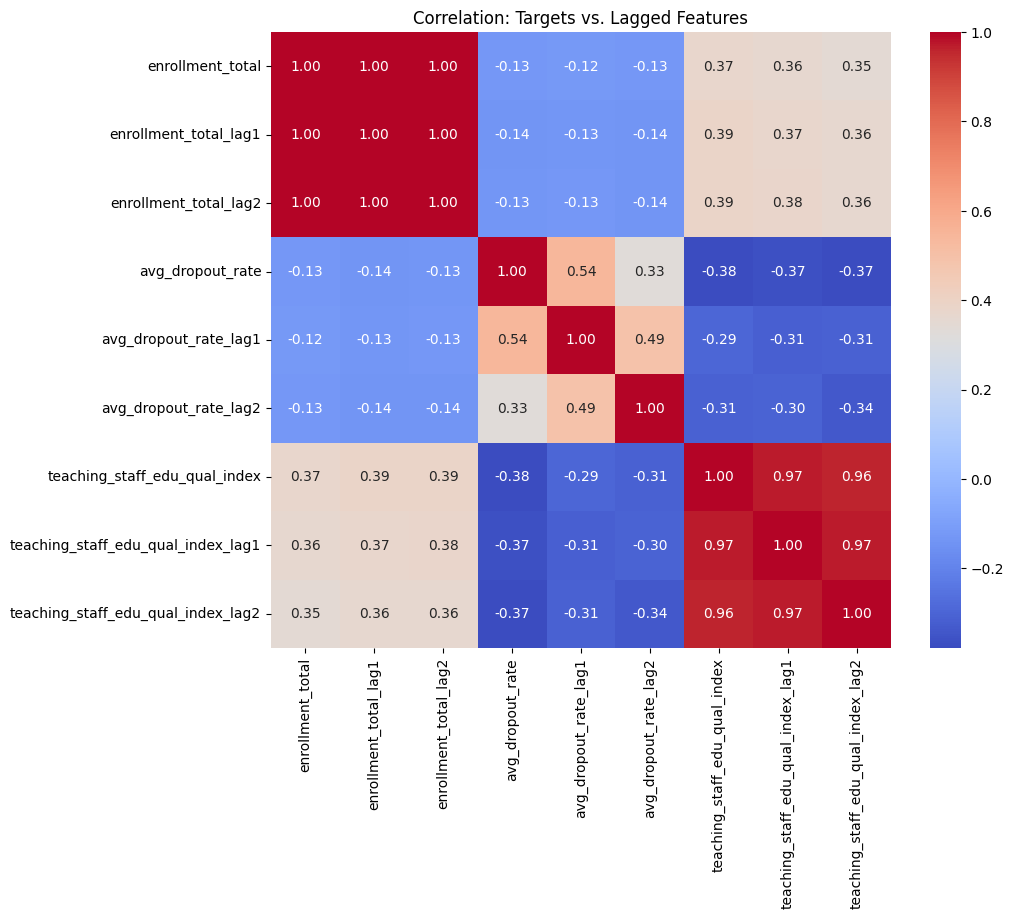

In [12]:
cols_to_corr = [
    'enrollment_total', 'enrollment_total_lag1', 'enrollment_total_lag2',
    'avg_dropout_rate', 'avg_dropout_rate_lag1', 'avg_dropout_rate_lag2',
    'teaching_staff_edu_qual_index', 'teaching_staff_edu_qual_index_lag1', 'teaching_staff_edu_qual_index_lag2'
]

plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_to_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation: Targets vs. Lagged Features")
plt.show()

## 4. Feature Selection & Transformation

We will keep the original numeric features but focus on the lagged ones. We skip the complex projection step.

In [13]:
features_enrollment = ['enrollment_total_lag1', 'enrollment_total_lag2', 'total_staff_total', 'num_classrooms']
features_dropout    = ['avg_dropout_rate_lag1', 'avg_dropout_rate_lag2', 'avg_transition_rate', 'teaching_staff_edu_qual_index']
features_teacher    = ['teaching_staff_edu_qual_index_lag1', 'teaching_staff_edu_qual_index_lag2', 'principal_avg_service_years', 'pb_fund_per_school_riel']

# Outlier removal
def remove_outliers_iforest(df, contamination=0.05):
    numeric_df = df.select_dtypes(include=['number']).dropna()
    iso = IsolationForest(contamination=contamination, random_state=42)
    preds = iso.fit_predict(numeric_df)
    return df.loc[numeric_df.index[preds == 1]].copy()

df = remove_outliers_iforest(df)

## 5. Model Training (2016-2024 for Train, 2025-2026 for Test)

We evaluate how well the model predicts the known 2025-2026 values using the lagged features.


--- Results for enrollment_total ---
        Model     R2        MAE       RMSE
        Ridge 0.9880  5615.2616  8853.7556
        Lasso 0.9864  5859.6575  9394.1190
      XGBoost 0.9863  5833.1469  9447.9546
Random Forest 0.9862  5701.3638  9484.6039
          GBR 0.9849  6202.3399  9917.3904
 SVR (Linear) 0.0092 68560.6748 80327.8116
    SVR (RBF) 0.0052 68630.7437 80489.2660


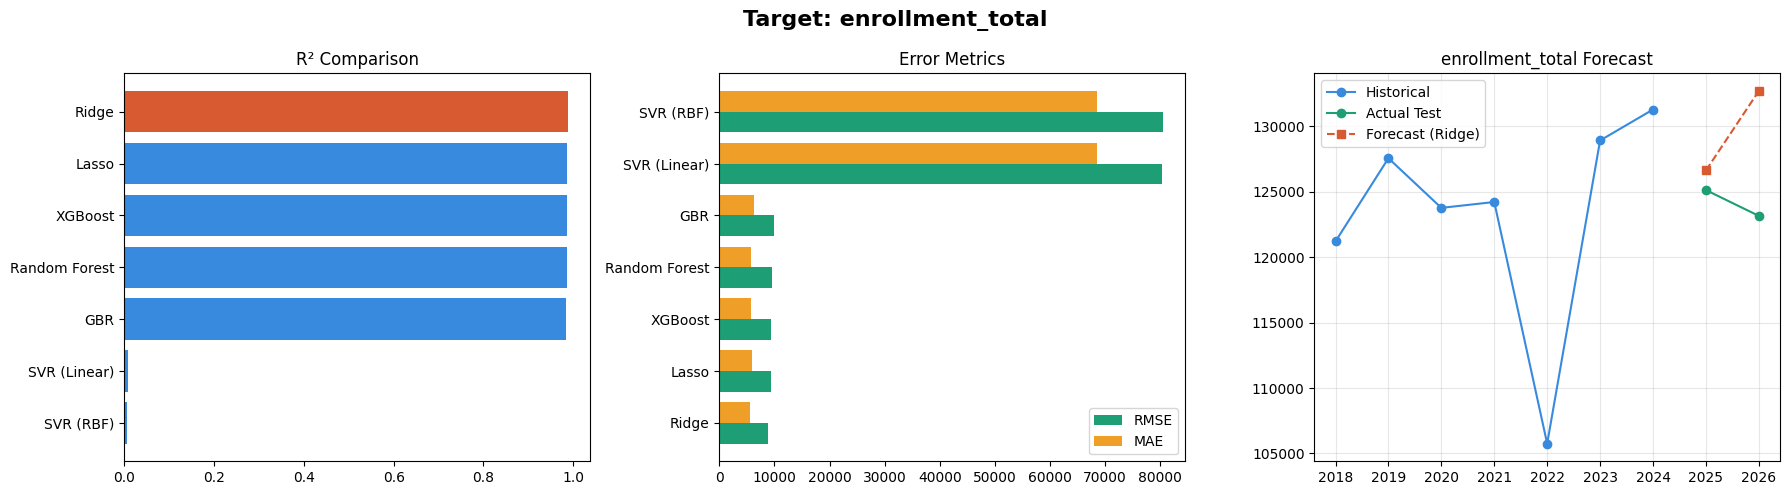


--- Results for avg_dropout_rate ---
        Model      R2    MAE   RMSE
 SVR (Linear)  0.2592 1.2041 1.4239
Random Forest  0.0555 1.3199 1.6079
        Ridge -0.0646 1.4844 1.7069
          GBR -0.1642 1.3789 1.7850
      XGBoost -0.1648 1.3560 1.7855
    SVR (RBF) -0.1894 1.4488 1.8043
        Lasso -0.2088 1.6096 1.8189


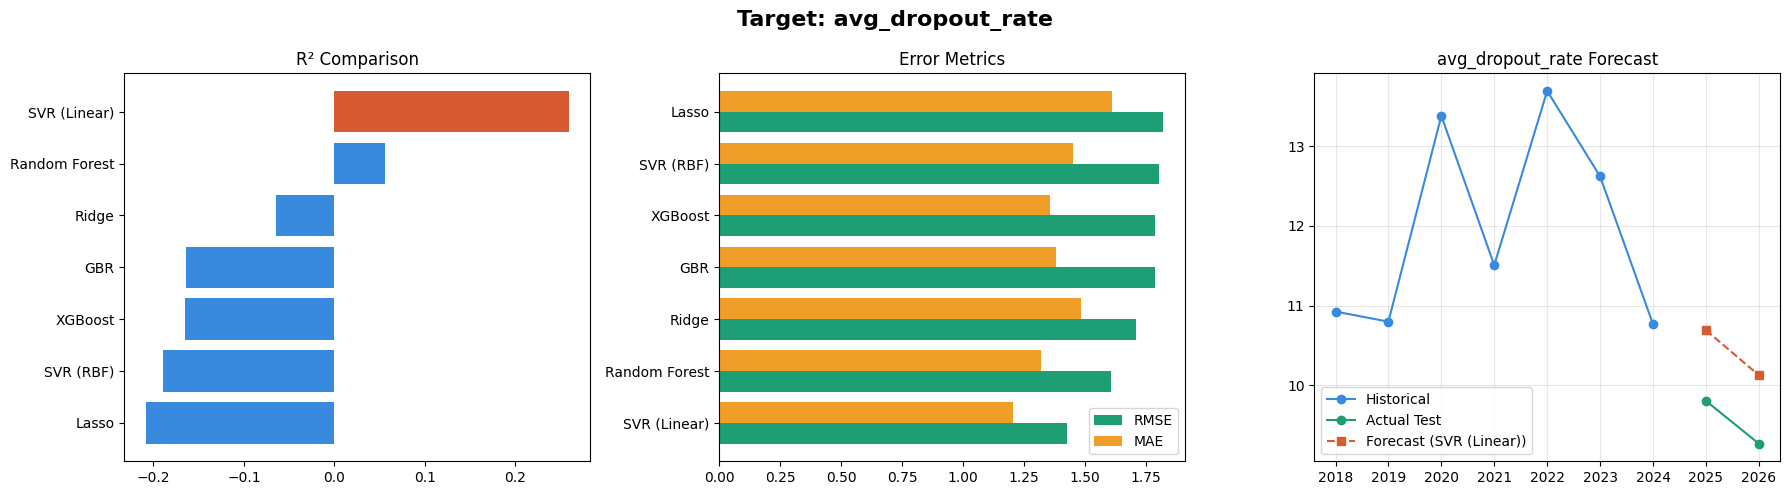


--- Results for teaching_staff_edu_qual_index ---
        Model      R2    MAE   RMSE
 SVR (Linear)  0.9067 0.0396 0.0495
        Ridge  0.8927 0.0455 0.0531
Random Forest  0.8763 0.0464 0.0570
          GBR  0.8605 0.0471 0.0605
      XGBoost  0.8600 0.0519 0.0606
    SVR (RBF)  0.5117 0.0855 0.1132
        Lasso -0.3438 0.1488 0.1878


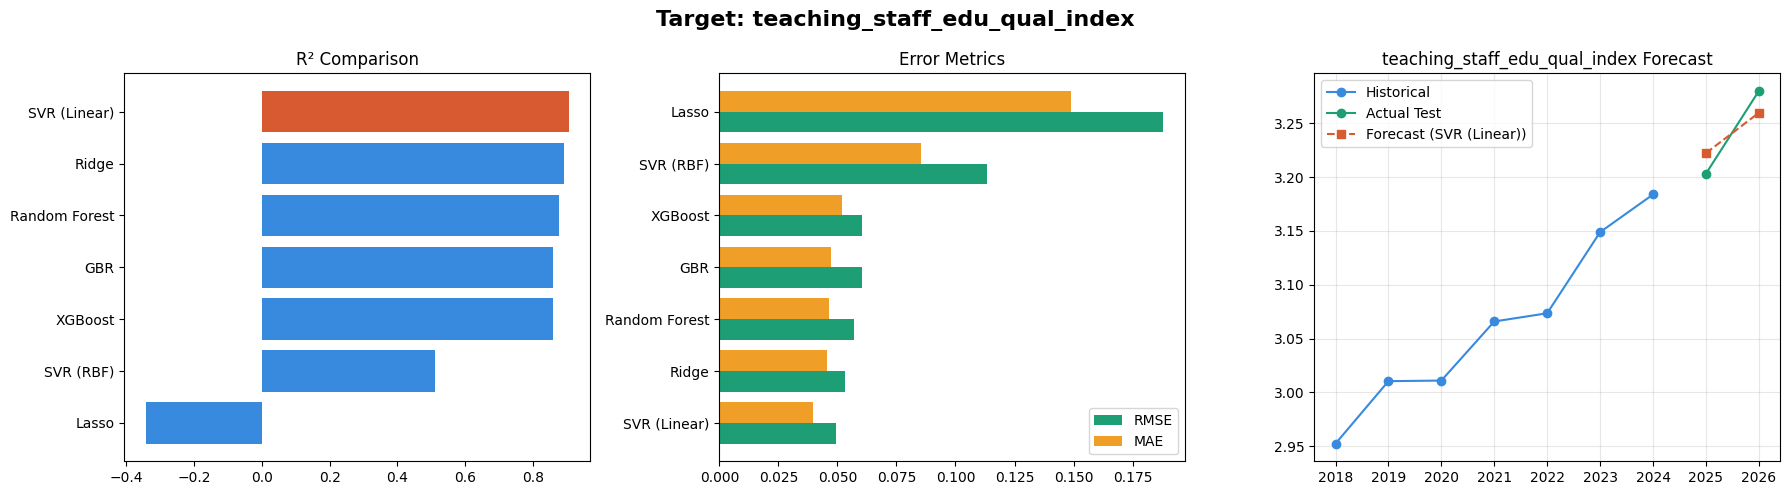

In [14]:
def select_and_forecast_lag(df, target, features, train_years=(2016, 2024), val_years=(2025, 2026)):
    """
    Evaluates 7 models on lag features, selects best, and plots results.
    """
    train_mask = df['Year'].between(*train_years)
    val_mask   = df['Year'].between(*val_years)

    X_train = df.loc[train_mask, features]
    y_train = df.loc[train_mask, target]
    X_val   = df.loc[val_mask, features]
    y_val   = df.loc[val_mask, target]

    imputer = SimpleImputer(strategy='median')
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=features)
    X_val_imp   = pd.DataFrame(imputer.transform(X_val), columns=features)

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_imp)
    X_val_sc   = scaler.transform(X_val_imp)

    models = {
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'XGBoost':       xgb.XGBRegressor(n_estimators=100, random_state=42),
        'Ridge':         Ridge(alpha=1.0),
        'Lasso':         Lasso(alpha=0.1),
        'GBR':           GradientBoostingRegressor(n_estimators=100, random_state=42),
        'SVR (RBF)':     SVR(kernel='rbf', C=10, epsilon=0.1),
        'SVR (Linear)':  SVR(kernel='linear', C=1)
    }

    records, val_preds = [], {}
    for name, model in models.items():
        X_tr = X_train_sc if 'SVR' in name else X_train_imp
        X_v  = X_val_sc   if 'SVR' in name else X_val_imp
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_v)
        records.append({
            'Model': name,
            'R2':    round(r2_score(y_val, y_pred), 4),
            'MAE':   round(mean_absolute_error(y_val, y_pred), 4),
            'RMSE':  round(np.sqrt(mean_squared_error(y_val, y_pred)), 4)
        })
        val_preds[name] = y_pred

    results_df = pd.DataFrame(records).sort_values('R2', ascending=False).reset_index(drop=True)
    best_name = results_df.iloc[0]['Model']
    best_preds = val_preds[best_name]

    print(f"\n--- Results for {target} ---")
    print(results_df.to_string(index=False))

    # ── Plots ──────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 5))

    # 1. R2 Plot
    ax1 = fig.add_subplot(1, 3, 1)
    sorted_r2 = results_df.sort_values('R2')
    colors = ['#D85A30' if m == best_name else '#378ADD' for m in sorted_r2['Model']]
    ax1.barh(sorted_r2['Model'], sorted_r2['R2'], color=colors)
    ax1.set_title('R² Comparison')

    # 2. Error Plot
    ax2 = fig.add_subplot(1, 3, 2)
    x_pos = np.arange(len(results_df))
    ax2.barh(x_pos - 0.2, results_df['RMSE'], 0.4, label='RMSE', color='#1D9E75')
    ax2.barh(x_pos + 0.2, results_df['MAE'], 0.4, label='MAE', color='#EF9F27')
    ax2.set_yticks(x_pos)
    ax2.set_yticklabels(results_df['Model'])
    ax2.set_title('Error Metrics')
    ax2.legend()

    # 3. Forecast Plot
    ax3 = fig.add_subplot(1, 3, 3)
    hist_years = sorted(df[df['Year'] < val_years[0]]['Year'].unique())
    hist_vals  = df[df['Year'] < val_years[0]].groupby('Year')[target].mean()
    
    actual_years = sorted(df[df['Year'].between(*val_years)]['Year'].unique())
    actual_vals  = df[df['Year'].between(*val_years)].groupby('Year')[target].mean()
    
    # Aggregate predictions by year
    pred_df = pd.DataFrame({'Year': df.loc[val_mask, 'Year'], 'Pred': best_preds})
    pred_vals = pred_df.groupby('Year')['Pred'].mean()

    ax3.plot(hist_years, hist_vals, label='Historical', color='#378ADD', marker='o')
    ax3.plot(actual_years, actual_vals, label='Actual Test', color='#1D9E75', marker='o')
    ax3.plot(actual_years, pred_vals, label=f'Forecast ({best_name})', color='#D85A30', linestyle='--', marker='s')
    
    ax3.set_title(f'{target} Forecast')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.suptitle(f'Target: {target}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return results_df, models[best_name], imputer, scaler

res_e, model_e, imp_e, scl_e = select_and_forecast_lag(df, 'enrollment_total', features_enrollment)
res_d, model_d, imp_d, scl_d = select_and_forecast_lag(df, 'avg_dropout_rate', features_dropout)
res_t, model_t, imp_t, scl_t = select_and_forecast_lag(df, 'teaching_staff_edu_qual_index', features_teacher)


## 6. Comparison Table: Original vs. Lag-Based Model

Let's compare the performance of this approach against the previous Feature Projection approach.

In [15]:
comparison_data = {
    'Target': ['Enrollment', 'Dropout Rate', 'Teacher Quality'],
    'Original Model (R2)': [0.9814, -0.0010, 0.5193],
    'Lag-Based Model (R2)': [
        res_e.iloc[0]['R2'],
        res_d.iloc[0]['R2'],
        res_t.iloc[0]['R2']
    ]
}

comp_df = pd.DataFrame(comparison_data)
comp_df['Improvement'] = comp_df['Lag-Based Model (R2)'] - comp_df['Original Model (R2)']
print(comp_df.to_string(index=False))

         Target  Original Model (R2)  Lag-Based Model (R2)  Improvement
     Enrollment               0.9814                0.9880       0.0066
   Dropout Rate              -0.0010                0.2592       0.2602
Teacher Quality               0.5193                0.9067       0.3874


## 7. Recursive Forecasting for 2027 and 2028

We now project the metrics to 2027 and 2028 by using predicted values as lags for the following year.

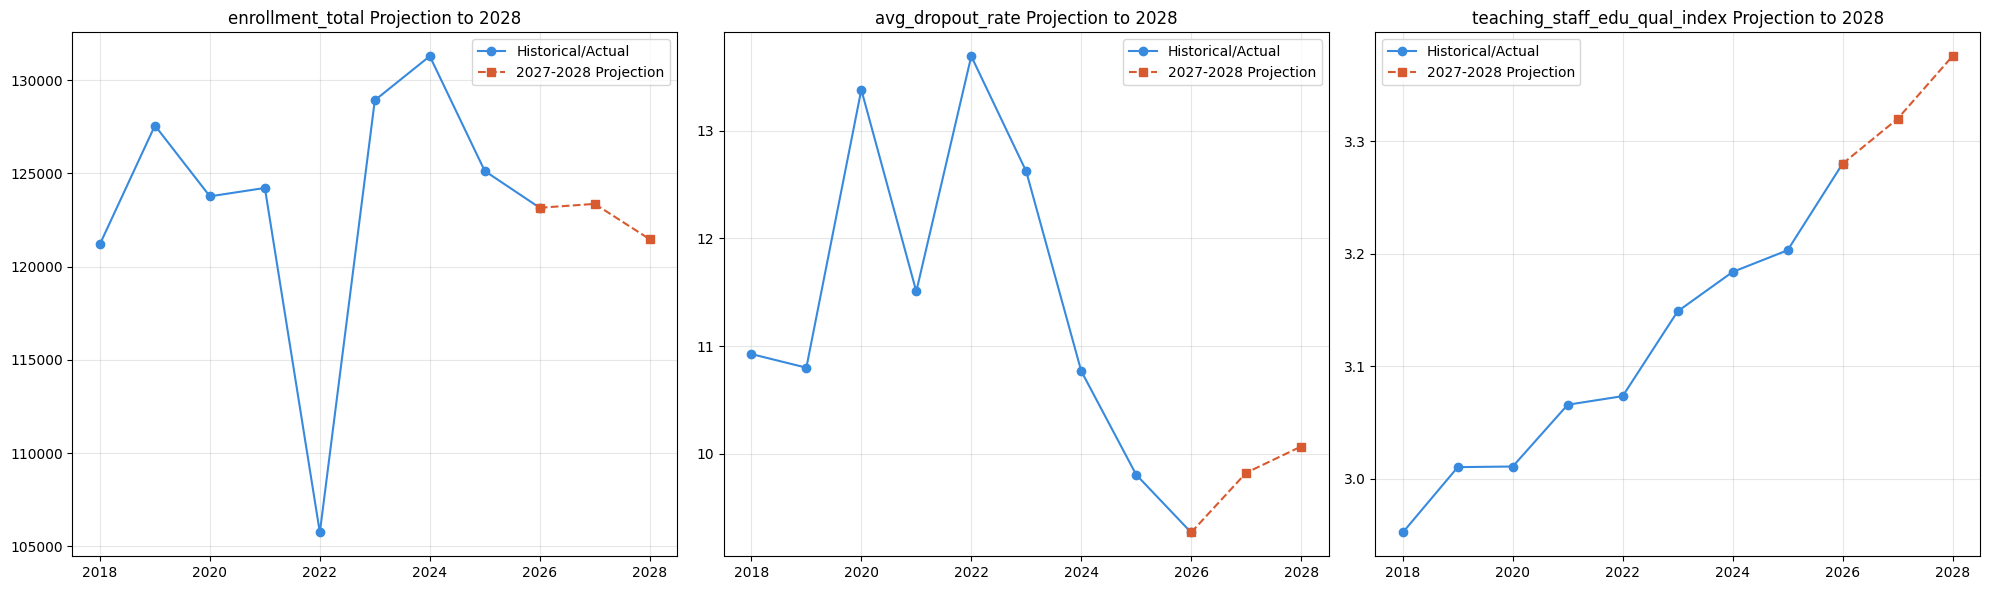


--- Summary of 2028 Projections (National Average) ---
enrollment_total                 121473.209635
avg_dropout_rate                     10.067813
teaching_staff_edu_qual_index         3.375466
dtype: float64


In [16]:
def recursive_forecast(df_input, target, model, imputer, scaler, features, future_years=[2027, 2028], other_feature_projections=[]):
    df_forecast = df_input.copy()
    provinces = df_forecast['Province'].unique()
    
    for year in future_years:
        for prov in provinces:
            # Ensure row exists
            mask = (df_forecast['Province'] == prov) & (df_forecast['Year'] == year)
            if not mask.any():
                new_row = pd.DataFrame([{'Province': prov, 'Year': year}])
                df_forecast = pd.concat([df_forecast, new_row], ignore_index=True)
                mask = (df_forecast['Province'] == prov) & (df_forecast['Year'] == year)
            
            prov_data = df_forecast[df_forecast['Province'] == prov].sort_values('Year')
            
            feat_values = {}
            for f in features:
                if f.endswith('_lag1'):
                    base_feat = f.replace('_lag1', '')
                    past_df = prov_data[prov_data['Year'] < year]
                    feat_values[f] = past_df[base_feat].iloc[-1] if not past_df.empty else 0
                elif f.endswith('_lag2'):
                    base_feat = f.replace('_lag2', '')
                    past_df = prov_data[prov_data['Year'] < year-1]
                    feat_values[f] = past_df[base_feat].iloc[-1] if not past_df.empty else 0
                elif f in prov_data.columns and not pd.isna(prov_data.loc[prov_data['Year'] == year, f].values[0]):
                    feat_values[f] = prov_data.loc[prov_data['Year'] == year, f].values[0]
                else:
                    if f in other_feature_projections:
                        last_vals = prov_data[prov_data['Year'] < year][f].dropna().tail(3).values
                        if len(last_vals) >= 2:
                            trend = (last_vals[-1] - last_vals[0]) / (len(last_vals) - 1)
                            feat_values[f] = last_vals[-1] + trend
                        elif len(last_vals) == 1:
                            feat_values[f] = last_vals[0]
                        else:
                            feat_values[f] = 0
                    else:
                        last_val = prov_data[prov_data['Year'] < year][f].dropna().iloc[-1] if not prov_data[prov_data['Year'] < year][f].dropna().empty else 0
                        feat_values[f] = last_val
            
            X_new = pd.DataFrame([feat_values])[features]
            X_new_imp = pd.DataFrame(imputer.transform(X_new), columns=features)
            X_new_final = scaler.transform(X_new_imp) if 'SVR' in str(type(model)) else X_new_imp
            
            pred = model.predict(X_new_final)[0]
            df_forecast.loc[mask, target] = pred
            for f, val in feat_values.items():
                if f in df_forecast.columns and pd.isna(df_forecast.loc[mask, f].values[0]):
                    df_forecast.loc[mask, f] = val
                    
    return df_forecast

other_feats = ['total_staff_total', 'num_classrooms', 'avg_transition_rate', 'principal_avg_service_years', 'pb_fund_per_school_riel']

# Forecast sequentially
df_f = recursive_forecast(df, 'teaching_staff_edu_qual_index', model_t, imp_t, scl_t, features_teacher, other_feature_projections=other_feats)
df_f = recursive_forecast(df_f, 'enrollment_total', model_e, imp_e, scl_e, features_enrollment, other_feature_projections=other_feats)
df_f = recursive_forecast(df_f, 'avg_dropout_rate', model_d, imp_d, scl_d, features_dropout, other_feature_projections=other_feats)

# --- Visualization ---
targets = ['enrollment_total', 'avg_dropout_rate', 'teaching_staff_edu_qual_index']
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, target in enumerate(targets):
    hist = df_f[df_f['Year'] <= 2026].groupby('Year')[target].mean()
    proj = df_f[df_f['Year'] >= 2026].groupby('Year')[target].mean()
    
    axes[i].plot(hist.index, hist.values, label='Historical/Actual', marker='o', color='#378ADD')
    axes[i].plot(proj.index, proj.values, label='2027-2028 Projection', marker='s', linestyle='--', color='#D85A30')
    axes[i].set_title(f'{target} Projection to 2028')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- Summary of 2028 Projections (National Average) ---")
print(df_f[df_f['Year'] == 2028][targets].mean())
